In [6]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
image_path = "../output_video/cropped_player.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

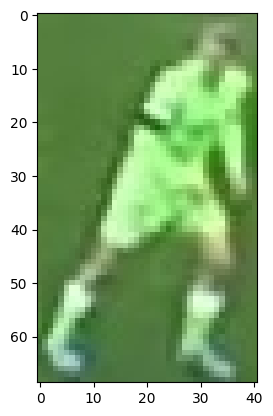

In [3]:
plt.imshow(image)
plt.show()

# We will be taking the Top half of the image 

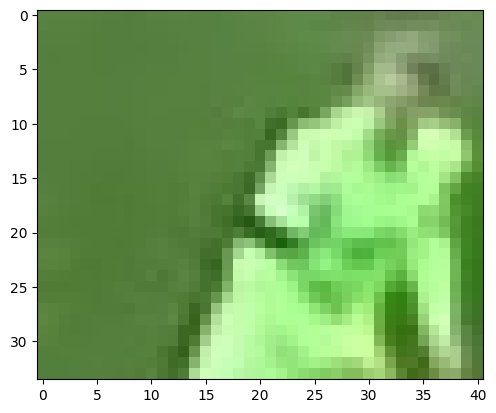

In [4]:
top_half_image = image[0:image.shape[0]//2, :]
plt.imshow(top_half_image)
plt.show()

###  Cluster the image into 2 cluster so that we remove the bg 

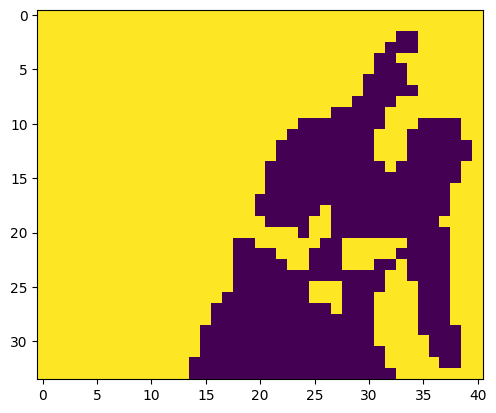

In [7]:
# reshape the imahe into 2D
image_2d = top_half_image.reshape(-1, 3)

#perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

#get the clusters lable 
lables = kmeans.labels_

#reshape the lables into the original image shape
clustered_image = lables.reshape(top_half_image.shape[0], top_half_image.shape[1])

# display the clustered image
plt.imshow(clustered_image)
plt.show()

In [8]:
corner_clusters = [clustered_image[0, 0], clustered_image[0, -1], clustered_image[-1, 0], clustered_image[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

1


In [9]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [10]:
kmeans.cluster_centers_[player_cluster]

array([168.3202934 , 233.12713936, 142.92176039])